In [48]:
#1. Try to explain why this research question might be of interest and to whom.

#This research question is relevant because it challenges a common assumption: that income is a primary driver of political preferences.

#This question that has implications for several stakeholders:
#. a - Political Parties and Campaign Strategists: Knowing whether income drives minority voters' party identification would help parties design
#. more effective outreach strategies and determine whether economic messaging or culturally relevant approaches are more appropriate.

#. b - Policy Makers: Understanding the relationship between income and political preferences among minorities can help shape more inclusive and
#. representative policy agendas.

#. c - Academic Researchers: This question contributes to the broader debate in political science about the determinants of voting behavior.
#. While traditional models emphasize economic factors such as income and social class, this study explores whether cultural and ethnic identity
#. may play a more significant role among minority populations in the UK.

#. d -  Ethnic Minority Communities: Exploring what shapes their political identity helps reinforce the importance of cultural representation in
#. politics.

#. e - Media and Public Opinion Analysts: Understanding the real factors behind minority voting patterns helps avoid oversimplified narratives
#. that reduce political behavior to income levels.


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency, pearsonr

In [50]:
2#. Locate relevant data file and accompanying documentation in the “stata” folder.

df_original = pd.read_stata('/content/BSE_2010.dta', convert_categoricals=False)
df_original.head()

,Unqid,Country,zgor,zq88,zq89,zq90,zq91_1,zq91_2,zq101,eq1,...,CitizenadjBA,CitizenadjIn,CitizenadjPa,CitizenadjBang,Citizenadjtotal,Popdensity,Intno,Inteth,Intsex,PSUIdentifier
0,100011,1,7,1,31,1,9,4.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
1,100013,1,3,2,49,6,1,NaN,3,NaN,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
2,100014,1,3,2,33,1,4,2.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
3,100015,1,3,2,37,1,2,0.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
4,100020,1,7,1,45,1,6,2.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148


In [51]:
3#. Perform any necessary transformations of data format type.

reader = pd.io.stata.StataReader('BSE_2010.dta')
variable_labels = reader.variable_labels()
df_labeled = df_original.copy()
df_labeled.rename(columns=variable_labels, inplace=True)
df_labeled.head()

,Unique ID,Country,GOVERNMENT OFFICE REGION,Gender,Age,Marital Status,N People Household,N People Household < 18,Ethnicity,Spouse/partner's ethnic group,...,Citizenship Survey adjusted number of Black Africans in the PSU,Citizenship Survey adjusted number of Indians in the PSU,Citizenship Survey adjusted number of Pakistanis in the PSU,Citizenship Survey adjusted number of Bangladeshis in the PSU,Citizenship Survey adjusted number of eligible in PSU (total),Population density of PSU per sq km,Interviewer number,Interviewer ethnicity,Interviewer gender,Primary Sampling Unit
0,100011,1,7,1,31,1,9,4.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148
1,100013,1,3,2,49,6,1,NaN,3,NaN,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
2,100014,1,3,2,33,1,4,2.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
3,100015,1,3,2,37,1,2,0.0,8,10.0,...,34.54,26.07,212.52,3.09,295.48,4977.419355,62138,7,1,1149
4,100020,1,7,1,45,1,6,2.0,8,10.0,...,138.16,304.94,359.52,74.16,919.58,5828.000000,69073,4,1,1148


In [52]:
print(df_labeled.columns.tolist())

['Unique ID', 'Country', 'GOVERNMENT OFFICE REGION', 'Gender', 'Age', 'Marital Status', 'N People Household', 'N People Household < 18', 'Ethnicity', "Spouse/partner's ethnic group", 'National Identities', 'Main National Identity', 'Main National Identity - EQ2 and EQ3 Combined', 'Belong Religion', 'Religion', 'Christian denomination', 'Muslim denomination', 'Importance of Religion', 'Religious Activities W Other People-How Often', 'Religious Activities Self- How Often', 'Party Identification', 'Closer to Party', 'Which Party Closer', 'Strength of Party Identification', 'Interest in 2010 General Election', 'On Electoral Register-Where Living', 'On Electoral Register-Another Address', 'On Electoral Register-No', 'On Electoral Register-DK', 'On Electoral Register-Refused', 'R Filled in Voter Form Themselves', 'Who filled in voter form for R', 'Voter form in English?', 'Not on Register: Not Entitled to Vote', 'Not on Register: Mistake', "Not on Register: Don't Know How to Register", "Not 

In [53]:
for i, col in enumerate(df_labeled.columns):
    print(f"{i}. {col}")

0. Unique ID
1. Country
2. GOVERNMENT OFFICE REGION
3. Gender
4. Age
5. Marital Status
6. N People Household
7. N People Household < 18
8. Ethnicity
9. Spouse/partner's ethnic group
10. National Identities
11. Main National Identity
12. Main National Identity - EQ2 and EQ3 Combined
13. Belong Religion
14. Religion
15. Christian denomination
16. Muslim denomination
17. Importance of Religion
18. Religious Activities W Other People-How Often
19. Religious Activities Self- How Often
20. Party Identification
21. Closer to Party
22. Which Party Closer
23. Strength of Party Identification
24. Interest in 2010 General Election
25. On Electoral Register-Where Living
26. On Electoral Register-Another Address
27. On Electoral Register-No
28. On Electoral Register-DK
29. On Electoral Register-Refused
30. R Filled in Voter Form Themselves
31. Who filled in voter form for R
32. Voter form in English?
33. Not on Register: Not Entitled to Vote
34. Not on Register: Mistake
35. Not on Register: Don't K

In [54]:
# Read using original nomenclature, without renaming.

for i, col in enumerate(df_original.columns):
    label = variable_labels.get(col, 'Sin etiqueta')
    print(f"{i}. {col:40s} -> {label}")

0. Unqid                                    -> Unique ID
1. Country                                  -> Country
2. zgor                                     -> GOVERNMENT OFFICE REGION
3. zq88                                     -> Gender
4. zq89                                     -> Age
5. zq90                                     -> Marital Status
6. zq91_1                                   -> N People Household
7. zq91_2                                   -> N People Household < 18
8. zq101                                    -> Ethnicity
9. eq1                                      -> Spouse/partner's ethnic group
10. eq2                                      -> National Identities
11. eq3                                      -> Main National Identity
12. eq3comb                                  -> Main National Identity - EQ2 and EQ3 Combined
13. zq106_1                                  -> Belong Religion
14. eq106_a                                  -> Religion
15. eq106_c             

In [55]:
#4. Identify variables of interest and specify their type.

df_important = df_labeled[['Unique ID','Country','Gender','Age','Closer to Party','Importance of Religion','Ethnicity','Feelings-Labour Party','Feelings-Conservative Party',
'Feelings-Liberal Democrats','Feelings-Green Party','Feelings_BNP','Feelings-UKIP','Feelings-SNP','Feelings-Plaid Cymru','Democracy Satisfaction','Pol Activity-Good Way Benefits Self & Family',
'Pol Activity-Too Much Time & Effort','Pol Activity-Good Way Group Benefits','Annual Household Income','Party Vote 2010 General Election','Party Best For Ethnic Minorities',
'Five Ethnicities']]
df_important.head()

,Unique ID,Country,Gender,Gender,Age,Age,Closer to Party,Importance of Religion,Ethnicity,Feelings-Labour Party,...,Feelings-SNP,Feelings-Plaid Cymru,Democracy Satisfaction,Pol Activity-Good Way Benefits Self & Family,Pol Activity-Too Much Time & Effort,Pol Activity-Good Way Group Benefits,Annual Household Income,Party Vote 2010 General Election,Party Best For Ethnic Minorities,Five Ethnicities
0,100011,1,1,NaN,31,NaN,NaN,2.0,8,9,...,NaN,NaN,2,4,4,4,13,NaN,1,4
1,100013,1,2,-3.0,49,49.0,NaN,3.0,3,3,...,NaN,NaN,4,4,1,1,4,NaN,-1,1
2,100014,1,2,NaN,33,NaN,2.0,1.0,8,5,...,NaN,NaN,3,4,3,2,4,3.0,-1,4
3,100015,1,2,NaN,37,NaN,NaN,2.0,8,8,...,NaN,NaN,1,2,2,2,4,1.0,1,4
4,100020,1,1,NaN,45,NaN,NaN,2.0,8,10,...,NaN,NaN,1,2,2,2,3,3.0,1,4


In [56]:
data = {
    'Variable': [
        'Unique ID', 'Country', 'Gender', 'Age', 'Party Identification',
        'Closer to Party', 'Importance of Religion', 'Ethnicity',
        'Feelings-Labour Party', 'Feelings-Conservative Party',
        'Feelings-Liberal Democrats', 'Feelings-Green Party',
        'Feelings_BNP', 'Feelings-UKIP', 'Feelings-SNP',
        'Feelings-Plaid Cymru', 'Democracy Satisfaction',
        'Pol Activity-Good Way Benefits Self & Family',
        'Pol Activity-Too Much Time & Effort',
        'Pol Activity-Good Way Group Benefits',
        'Annual Household Income', 'Party Vote 2010',
        'Party Best For Ethnic Minorities', 'Five Ethnicities'
    ],
    'Type': [
        'Quantitative', 'Qualitative', 'Qualitative', 'Quantitative', 'Qualitative',
        'Qualitative', 'Qualitative', 'Qualitative',
        'Quantitative', 'Quantitative',
        'Quantitative', 'Quantitative',
        'Quantitative', 'Quantitative', 'Quantitative',
        'Quantitative', 'Qualitative',
        'Qualitative',
        'Qualitative',
        'Qualitative',
        'Qualitative', 'Qualitative',
        'Qualitative', 'Qualitative'
    ]
}

df_variables = pd.DataFrame(data)
df_variables

,Variable,Type
0,Unique ID,Quantitative
1,Country,Qualitative
2,Gender,Qualitative
3,Age,Quantitative
4,Party Identification,Qualitative
5,Closer to Party,Qualitative
6,Importance of Religion,Qualitative
7,Ethnicity,Qualitative
8,Feelings-Labour Party,Quantitative
9,Feelings-Conservative Party,Quantitative


In [57]:
#5. In case a variable is ordinal or nominal, list the possible categories and their meaning.

# Filter only the qualitative variables in df_variables
df_qualitative = df_variables[df_variables['Type'] == 'Qualitative'].copy()

# Add original code and subtype
codes = {
    'Country': 'Country',
    'Gender': 'zq88',
    'Party Identification': 'bq9_1',
    'Closer to Party': 'bq9_2',
    'Importance of Religion': 'eq4',
    'Ethnicity': 'zq101',
    'Democracy Satisfaction': 'bq61',
    'Pol Activity-Good Way Benefits Self & Family': 'bq18_3',
    'Pol Activity-Too Much Time & Effort': 'bq18_4',
    'Pol Activity-Good Way Group Benefits': 'bq18_5',
    'Annual Household Income': 'zqinc',
    'Party Vote 2010': 'bq12_2',
    'Party Best For Ethnic Minorities': 'bq71',
    'Five Ethnicities': 'ScreenEthQairre',
}

subtypes = {
    'Country': 'Nominal',
    'Gender': 'Nominal',
    'Party Identification': 'Nominal',
    'Closer to Party': 'Nominal',
    'Importance of Religion': 'Ordinal',
    'Ethnicity': 'Nominal',
    'Democracy Satisfaction': 'Ordinal',
    'Pol Activity-Good Way Benefits Self & Family': 'Ordinal',
    'Pol Activity-Too Much Time & Effort': 'Ordinal',
    'Pol Activity-Good Way Group Benefits': 'Ordinal',
    'Annual Household Income': 'Ordinal',
    'Party Vote 2010': 'Nominal',
    'Party Best For Ethnic Minorities': 'Nominal',
    'Five Ethnicities': 'Nominal',
}

df_qualitative['Code'] = df_qualitative['Variable'].map(codes)
df_qualitative['Subtype'] = df_qualitative['Variable'].map(subtypes)

# Add categories from file
value_labels_lower = {k.lower(): v for k, v in reader.value_labels().items()}

def get_categories(code):
    if code.lower() in value_labels_lower:
        mapeo = value_labels_lower[code.lower()]
        return "; ".join([f"{k}={v}" for k, v in sorted(mapeo.items())])
    else:
        vals = sorted(df_original[code].dropna().unique())
        return "; ".join([str(int(v)) for v in vals])

df_qualitative['Categories'] = df_qualitative['Code'].apply(get_categories)
df_qualitative = df_qualitative[['Variable', 'Code', 'Subtype', 'Categories']]

# Complete missing categories from the dictionary
manual_categories = {
    'bq9_2':           '-2=Refused; -1=Don\'t Know; 1=Yes; 2=No',
    'bq18_3':          '-2=Refused; -1=Don\'t Know; 1=Strongly agree; 2=Agree; 3=Neither agree nor disagree; 4=Disagree; 5=Strongly disagree',
    'bq18_4':          '-2=Refused; -1=Don\'t Know; 1=Strongly agree; 2=Agree; 3=Neither agree nor disagree; 4=Disagree; 5=Strongly disagree',
    'bq18_5':          '-2=Refused; -1=Don\'t Know; 1=Strongly agree; 2=Agree; 3=Neither agree nor disagree; 4=Disagree; 5=Strongly disagree',
    'ScreenEthQairre': '1=Indian; 2=Pakistani; 3=Bangladeshi; 4=Black Caribbean; 5=Black African',
}

for code, categories in manual_categories.items():
    df_qualitative.loc[df_qualitative['Code'] == code, 'Categories'] = categories

df_qualitative

,Variable,Code,Subtype,Categories
1,Country,Country,Nominal,1=ENGLAND; 2=SCOTLAND; 3=WALES
2,Gender,zq88,Nominal,1=Male; 2=Female; 3=Not Stated
4,Party Identification,bq9_1,Nominal,-2=Refused; -1=Don't Know; 1=None/No; 2=Labour...
5,Closer to Party,bq9_2,Nominal,-2=Refused; -1=Don't Know; 1=Yes; 2=No
6,Importance of Religion,eq4,Ordinal,-2=Refused; -1=Don't Know; 1=Extremely importa...
7,Ethnicity,zq101,Nominal,-2=Refused; -1=Don't Know; 1=White - British; ...
16,Democracy Satisfaction,bq61,Ordinal,-2=Refused; -1=Don't Know; 1=Very satisfied; 2...
17,Pol Activity-Good Way Benefits Self & Family,bq18_3,Ordinal,-2=Refused; -1=Don't Know; 1=Strongly agree; 2...
18,Pol Activity-Too Much Time & Effort,bq18_4,Ordinal,-2=Refused; -1=Don't Know; 1=Strongly agree; 2...
19,Pol Activity-Good Way Group Benefits,bq18_5,Ordinal,-2=Refused; -1=Don't Know; 1=Strongly agree; 2...


In [58]:
#6. Define the analysis required to answer the RQ and explain why you have chosen this particular analysis.
#   The research question is: "Does Annual Household Income Play a Role in Minority’s Political Party Identification?"

# Define the mappings
ethnicity_labels = {1: 'Indian', 2: 'Pakistani', 3: 'Bangladeshi', 4: 'Black Caribbean', 5: 'Black African'}

closer_labels = {-2: 'Refused', -1: "Don't Know", 1: 'Yes', 2: 'No'}

identification_labels =  {
    -2: 'Refused',
    -1: "Don't Know",
    1: 'None/No',
    2: 'Labour',
    3: 'Conservatives',
    4: 'Liberal Democrats',
    5: 'SNP',
    6: 'Plaid Cymru',
    7: 'Green Party',
    8: 'UKIP',
    9: 'BNP',
    10: 'Coalition Conservative-Lib Dem',
    11: 'Other',
    12: 'Respect',
    15: 'Not Stated'
}

income_labels = {
    -2: 'Refused',
    -1: "Don't Know",
    1: '£0-5,000',
    2: '£5,001-10,000',
    3: '£10,001-15,000',
    4: '£15,001-20,000',
    5: '£20,001-25,000',
    6: '£25,001-30,000',
    7: '£30,001-35,000',
    8: '£35,001-40,000',
    9: '£41,000-45,000',
    10: '£45,001-50,000',
    11: '£50,001-60,000',
    12: '£60,001-70,000',
    13: '£70,001-80,000',
    14: '£80,001+',
    17: 'Not Stated'
}

# Order Income
income_order = list(income_labels.values())

# Create columns with labels
df_labeled['Five Ethnicities Label'] = df_labeled['Five Ethnicities'].map(ethnicity_labels)
df_labeled['Closer to Party Label'] = df_labeled['Closer to Party'].map(closer_labels)
df_labeled['Annual Household Income Label'] = df_labeled['Annual Household Income'].map(income_labels)
df_labeled['Party Identification Label'] = df_labeled['Party Identification'].map(identification_labels)


Closer to Party Label   Don't Know  No  Refused  Yes
Five Ethnicities Label                              
Bangladeshi                     15  76        6   23
Black African                    9  43        3   14
Black Caribbean                  8  84        2   30
Indian                           8  91        5   45
Pakistani                       21  68        4   30
-------------------------------------------------------
STATISTICAL RESULTS: Five Ethnicities vs Closer to Party
-------------------------------------------------------
chi_square statistic: 19.450
p_value:0.07824
dof:12
-------------------------------------------------------


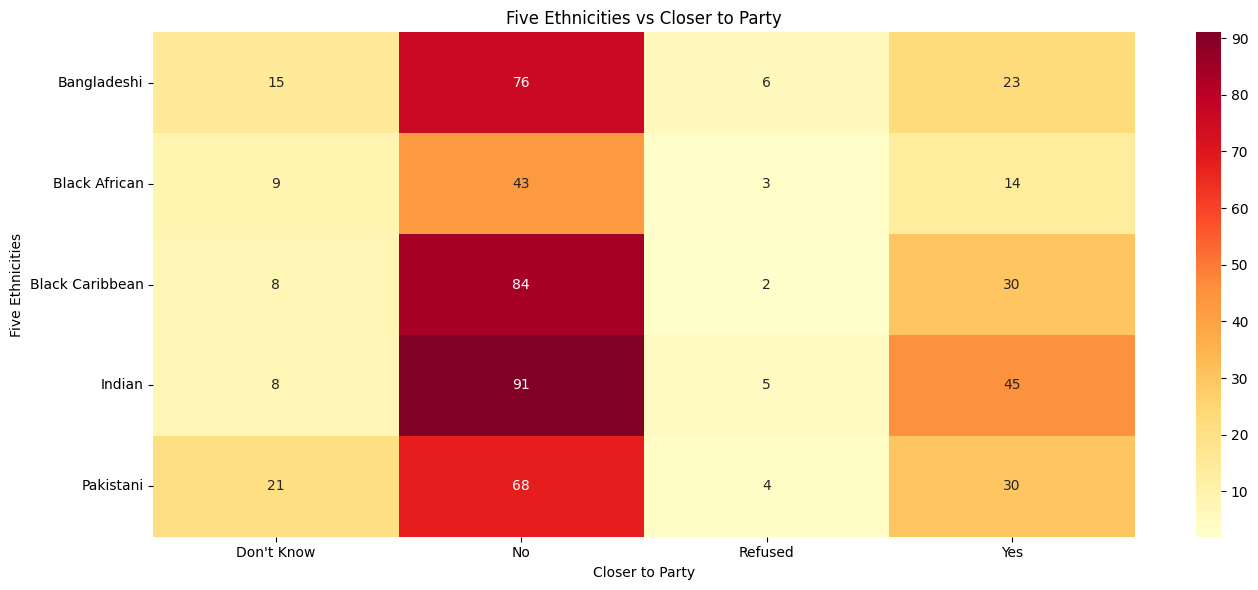

In [59]:
#Ethnicity vs Closer to Party.

# Crosstab
table1 = pd.crosstab(df_labeled['Five Ethnicities Label'], df_labeled['Closer to Party Label'])
print(table1)

chi2,p,dof,expected = chi2_contingency(table1)
print("-" * 55)
print(f"STATISTICAL RESULTS: Five Ethnicities vs Closer to Party")
print("-" * 55)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value:{p:.5f}")
print(f"dof:{dof}")
print("-" * 55)

plt.figure(figsize=(14, 6))
sns.heatmap(table1, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Five Ethnicities vs Closer to Party')
plt.xlabel('Closer to Party')
plt.ylabel('Five Ethnicities')
plt.tight_layout()
plt.show()

Annual Household Income Label  Refused  Don't Know  £0-5,000  £5,001-10,000  \
Five Ethnicities Label                                                        
Bangladeshi                        110          93        17             44   
Black African                       78          41        20             38   
Black Caribbean                    183         148        22             87   
Indian                             118          97        57             76   
Pakistani                          113          74        52             66   

Annual Household Income Label  £10,001-15,000  £15,001-20,000  £20,001-25,000  \
Five Ethnicities Label                                                          
Bangladeshi                                55              36              31   
Black African                              32              23               8   
Black Caribbean                            61              44              30   
Indian                                   

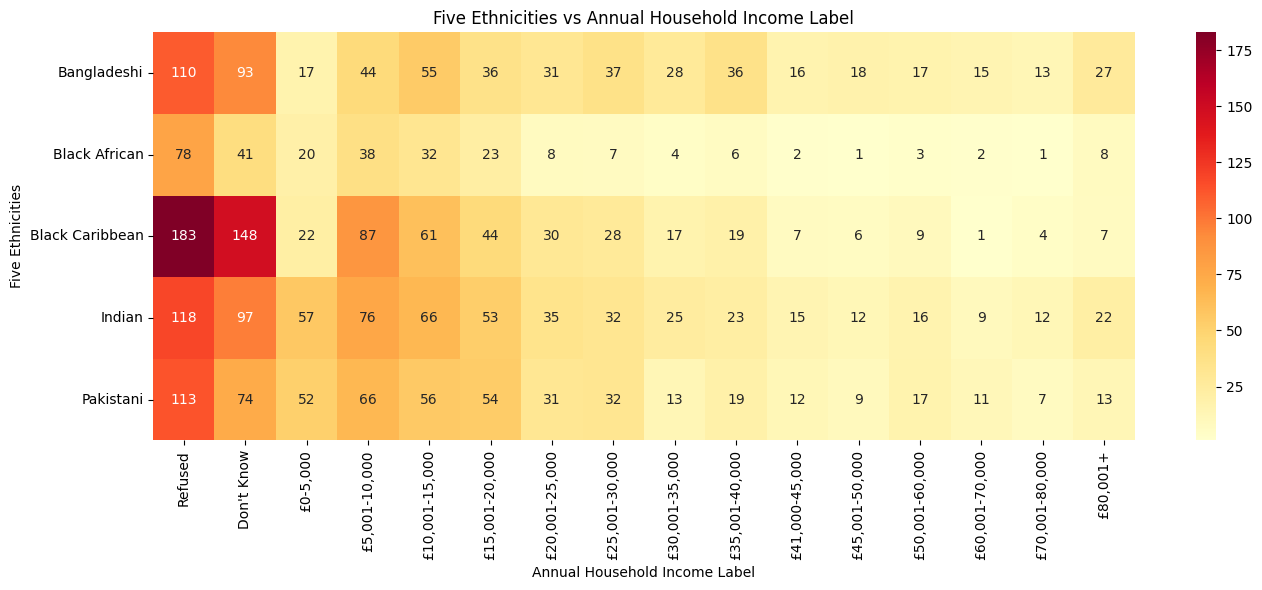

In [60]:
# Income vs Ethnicity

table2 = pd.crosstab(df_labeled['Five Ethnicities Label'], df_labeled['Annual Household Income Label'])
table2 = table2.reindex(columns=income_order).fillna(0).astype(int)
print(table2)

table2 = table2.loc[:, table2.sum() > 0]

chi2,p,dof,expected = chi2_contingency(table2)
print("-" * 75)
print(f"STATISTICAL RESULTS: Five Ethnicities vs Annual Household Income Label")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value:{p:.5f}")
print(f"dof:{dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table2, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Five Ethnicities vs Annual Household Income Label')
plt.xlabel('Annual Household Income Label')
plt.ylabel('Five Ethnicities')
plt.tight_layout()
plt.show()

Annual Household Income Label  Refused  Don't Know  £0-5,000  £5,001-10,000  \
Closer to Party Label                                                         
Don't Know                          11          16         3              4   
No                                 103          63        27             35   
Refused                             11           1         0              3   
Yes                                 33          26         9             16   

Annual Household Income Label  £10,001-15,000  £15,001-20,000  £20,001-25,000  \
Closer to Party Label                                                           
Don't Know                                  5               5               3   
No                                         21              30              10   
Refused                                     0               0               1   
Yes                                        13              11               6   

Annual Household Income Label  £25,001

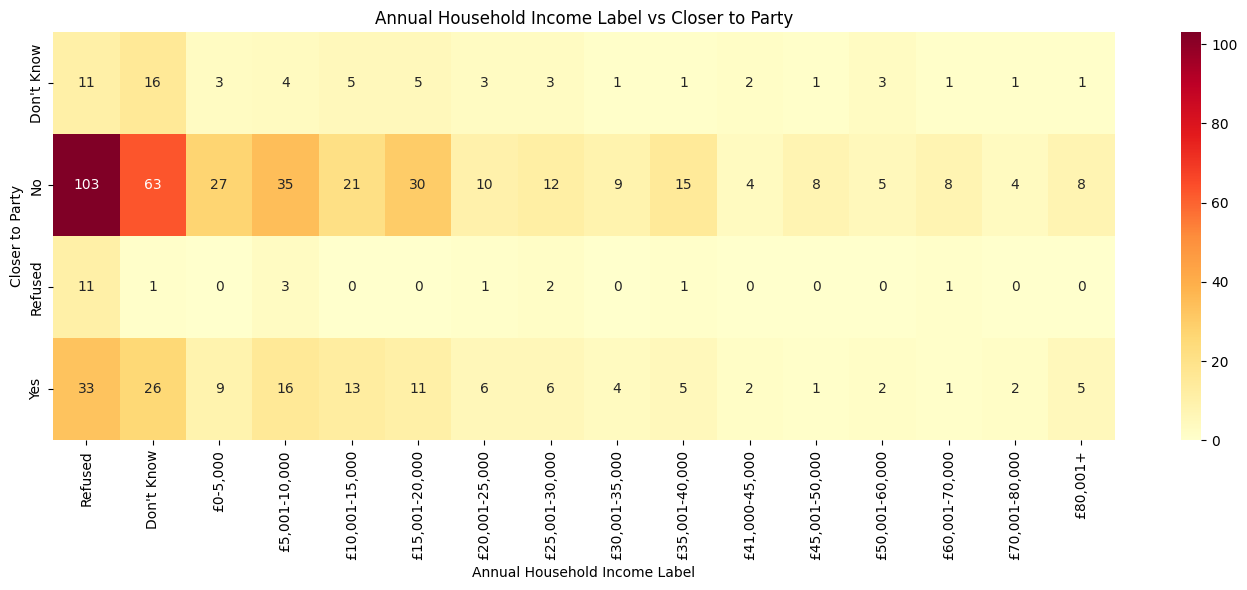

In [61]:
#Income vs Closer Party
table3 = pd.crosstab(df_labeled['Closer to Party Label'], df_labeled['Annual Household Income Label'])
table3 = table3.reindex(columns=income_order).fillna(0).astype(int)
print(table3)

table3 = table3.loc[:, table3.sum() > 0]

chi2,p,dof,expected = chi2_contingency(table3)
print("-" * 75)
print(f"STATISTICAL RESULTS: Annual Household Income Label vs Closer to Party")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value:{p:.5f}")
print(f"dof:{dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table3, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Annual Household Income Label vs Closer to Party')
plt.xlabel('Annual Household Income Label')
plt.ylabel('Closer to Party')
plt.tight_layout()
plt.show()

Annual Household Income Label   Refused  Don't Know  £0-5,000  £5,001-10,000  \
Party Identification Label                                                     
BNP                                   0           0         1              1   
Coalition Conservative-Lib Dem        0           0         0              1   
Conservatives                        41          38        11             19   
Don't Know                           41          43        15             22   
Green Party                           1           3         1              2   
Labour                              334         261        99            203   
Liberal Democrats                    57          37        15             24   
None/No                              94          58        23             31   
Other                                 2           2         0              0   
Refused                              25           5         1              6   
Respect                               3 

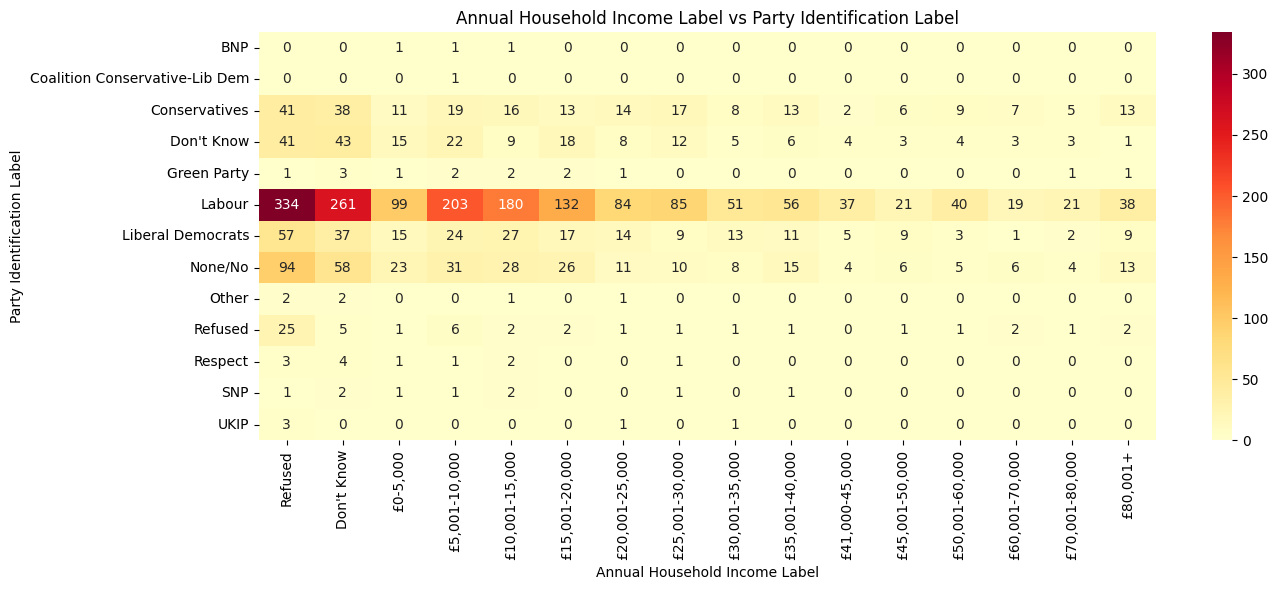

In [62]:
#Income vs Party Identification

table4 = pd.crosstab(df_labeled['Party Identification Label'], df_labeled['Annual Household Income Label'])
table4 = table4.reindex(columns=income_order).fillna(0).astype(int)
print(table4)

table4 = table4.loc[:, table4.sum() > 0]

chi2, p, dof, expected = chi2_contingency(table4)
print("-" * 75)
print(f"STATISTICAL RESULTS: Annual Household Income Label vs Party Identification Label")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value: {p:.5f}")
print(f"dof: {dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table4, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Annual Household Income Label vs Party Identification Label')
plt.xlabel('Annual Household Income Label')
plt.ylabel('Party Identification Label')
plt.tight_layout()
plt.show()


Party Identification Label  BNP  Coalition Conservative-Lib Dem  \
Five Ethnicities Label                                            
Bangladeshi                   1                               0   
Black African                 0                               0   
Black Caribbean               0                               0   
Indian                        2                               1   
Pakistani                     0                               0   

Party Identification Label  Conservatives  Don't Know  Green Party  Labour  \
Five Ethnicities Label                                                       
Bangladeshi                            91          45            2     315   
Black African                          23          22            2     153   
Black Caribbean                        55          43            3     367   
Indian                                 34          45            4     437   
Pakistani                              29          42         

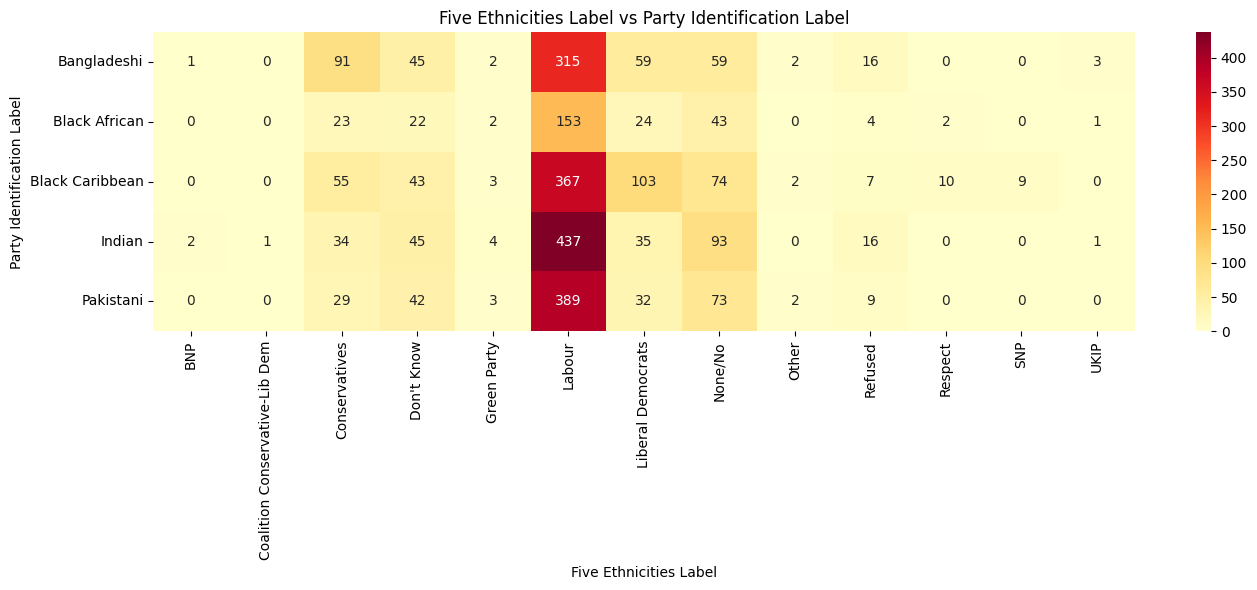

In [63]:
# Ethnicity vs Party Identification
table5 = pd.crosstab(df_labeled['Five Ethnicities Label'], df_labeled['Party Identification Label'])
print(table5)

chi2, p, dof, expected = chi2_contingency(table5)
print("-" * 75)
print(f"STATISTICAL RESULTS: Five Ethnicities Label vs Party Identification Label")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value: {p:.5f}")
print(f"dof: {dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table5, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Five Ethnicities Label vs Party Identification Label')
plt.xlabel('Five Ethnicities Label')
plt.ylabel('Party Identification Label')
plt.tight_layout()
plt.show()

In [64]:
#Clean -2 and -1

significant_income = df_labeled['Annual Household Income'] > 0
df_incomclean = df_labeled[significant_income]
df_incomclean.head()

,Unique ID,Country,GOVERNMENT OFFICE REGION,Gender,Age,Marital Status,N People Household,N People Household < 18,Ethnicity,Spouse/partner's ethnic group,...,Citizenship Survey adjusted number of eligible in PSU (total),Population density of PSU per sq km,Interviewer number,Interviewer ethnicity,Interviewer gender,Primary Sampling Unit,Five Ethnicities Label,Closer to Party Label,Annual Household Income Label,Party Identification Label
0,100011,1,7,1,31,1,9,4.0,8,10.0,...,919.58,5828.000000,69073,4,1,1148,Black Caribbean,NaN,"£70,001-80,000",Labour
1,100013,1,3,2,49,6,1,NaN,3,NaN,...,295.48,4977.419355,62138,7,1,1149,Indian,NaN,"£15,001-20,000",Labour
2,100014,1,3,2,33,1,4,2.0,8,10.0,...,295.48,4977.419355,62138,7,1,1149,Black Caribbean,No,"£15,001-20,000",None/No
3,100015,1,3,2,37,1,2,0.0,8,10.0,...,295.48,4977.419355,62138,7,1,1149,Black Caribbean,NaN,"£15,001-20,000",Labour
4,100020,1,7,1,45,1,6,2.0,8,10.0,...,919.58,5828.000000,69073,4,1,1148,Black Caribbean,NaN,"£10,001-15,000",Labour


Annual Household Income Label  Refused  Don't Know  £0-5,000  £5,001-10,000  \
Five Ethnicities Label                                                        
Bangladeshi                          0           0        17             44   
Black African                        0           0        20             38   
Black Caribbean                      0           0        22             87   
Indian                               0           0        57             76   
Pakistani                            0           0        52             66   

Annual Household Income Label  £10,001-15,000  £15,001-20,000  £20,001-25,000  \
Five Ethnicities Label                                                          
Bangladeshi                                55              36              31   
Black African                              32              23               8   
Black Caribbean                            61              44              30   
Indian                                   

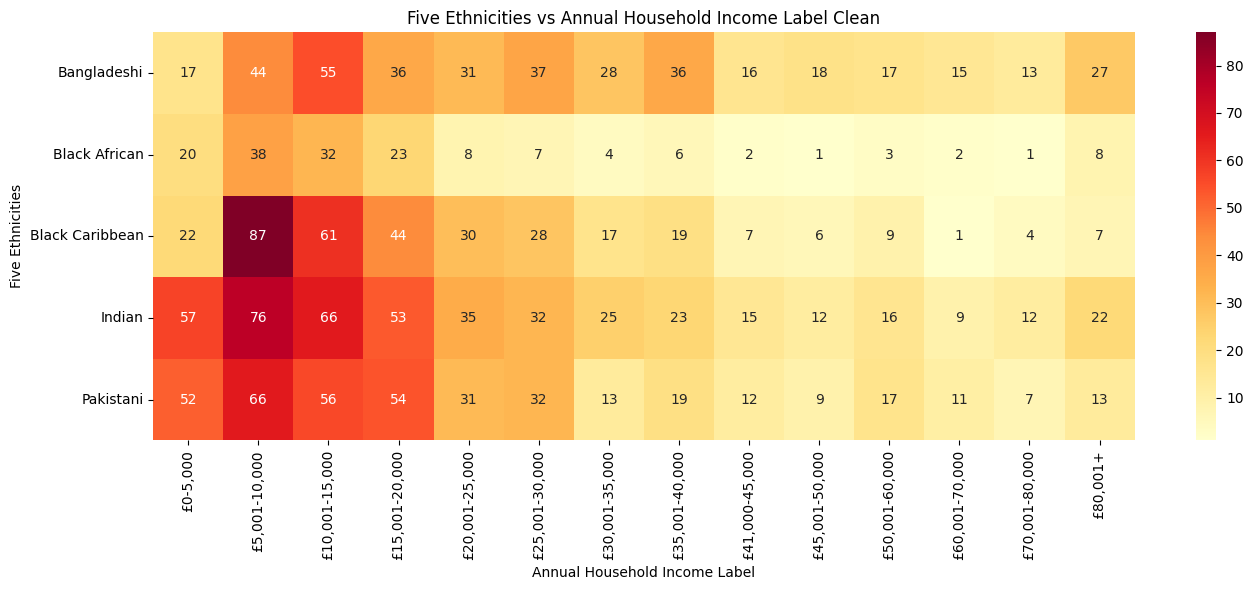

In [65]:
#Income Clean Vs Ethnicity

table_clean1 = pd.crosstab(df_incomclean['Five Ethnicities Label'], df_incomclean['Annual Household Income Label'])
table_clean1 = table_clean1.reindex(columns=income_order).fillna(0).astype(int)
print(table_clean1)

table_clean1 = table_clean1.loc[:, table_clean1.sum() > 0]

chi2,p,dof,expected = chi2_contingency(table_clean1)
print("-" * 75)
print(f"STATISTICAL RESULTS: Five Ethnicities vs Annual Household Income Label Clean")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value:{p:.5f}")
print(f"dof:{dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table_clean1, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Five Ethnicities vs Annual Household Income Label Clean')
plt.xlabel('Annual Household Income Label')
plt.ylabel('Five Ethnicities')
plt.tight_layout()
plt.show()

Annual Household Income Label  Refused  Don't Know  £0-5,000  £5,001-10,000  \
Closer to Party Label                                                         
Don't Know                           0           0         3              4   
No                                   0           0        27             35   
Refused                              0           0         0              3   
Yes                                  0           0         9             16   

Annual Household Income Label  £10,001-15,000  £15,001-20,000  £20,001-25,000  \
Closer to Party Label                                                           
Don't Know                                  5               5               3   
No                                         21              30              10   
Refused                                     0               0               1   
Yes                                        13              11               6   

Annual Household Income Label  £25,001

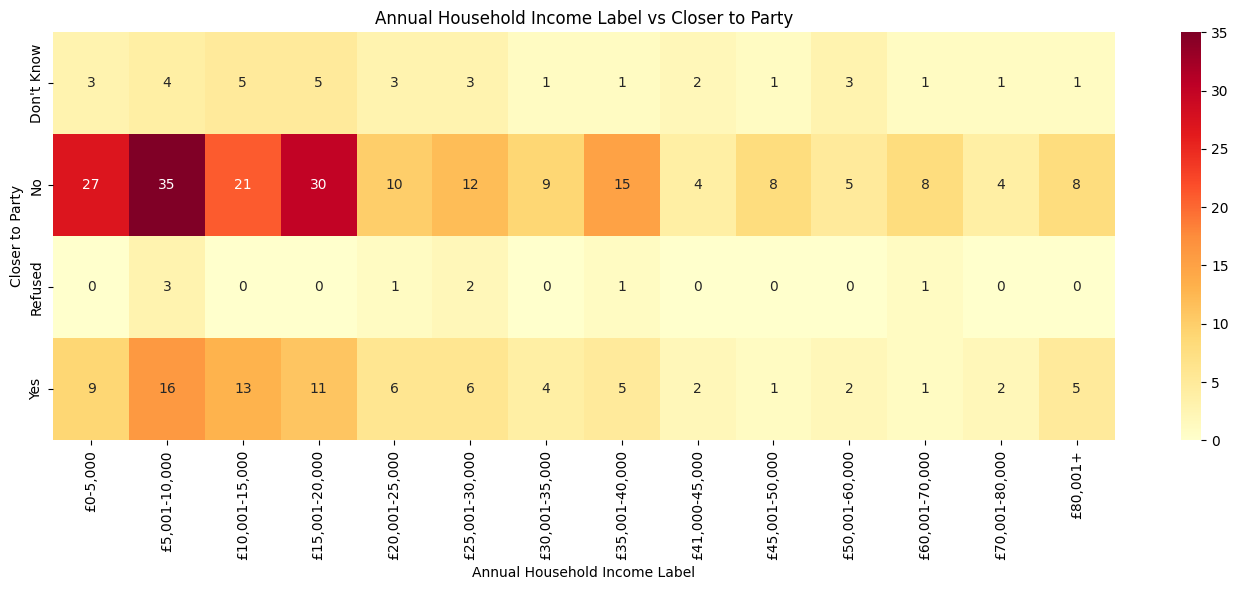

In [66]:
#Income Clean vs Closer to Party

table_clean2 = pd.crosstab(df_incomclean['Closer to Party Label'], df_incomclean['Annual Household Income Label'])
table_clean2 = table_clean2.reindex(columns=income_order).fillna(0).astype(int)
print(table_clean2)

table_clean2 = table_clean2.loc[:, table_clean2.sum() > 0]

chi2,p,dof,expected = chi2_contingency(table_clean2)
print("-" * 75)
print(f"STATISTICAL RESULTS: Annual Household Income Label vs Closer to Party")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value:{p:.5f}")
print(f"dof:{dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table_clean2, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Annual Household Income Label vs Closer to Party')
plt.xlabel('Annual Household Income Label')
plt.ylabel('Closer to Party')
plt.tight_layout()
plt.show()


Annual Household Income Label   Refused  Don't Know  £0-5,000  £5,001-10,000  \
Party Identification Label                                                     
BNP                                   0           0         1              1   
Coalition Conservative-Lib Dem        0           0         0              1   
Conservatives                         0           0        11             19   
Don't Know                            0           0        15             22   
Green Party                           0           0         1              2   
Labour                                0           0        99            203   
Liberal Democrats                     0           0        15             24   
None/No                               0           0        23             31   
Other                                 0           0         0              0   
Refused                               0           0         1              6   
Respect                               0 

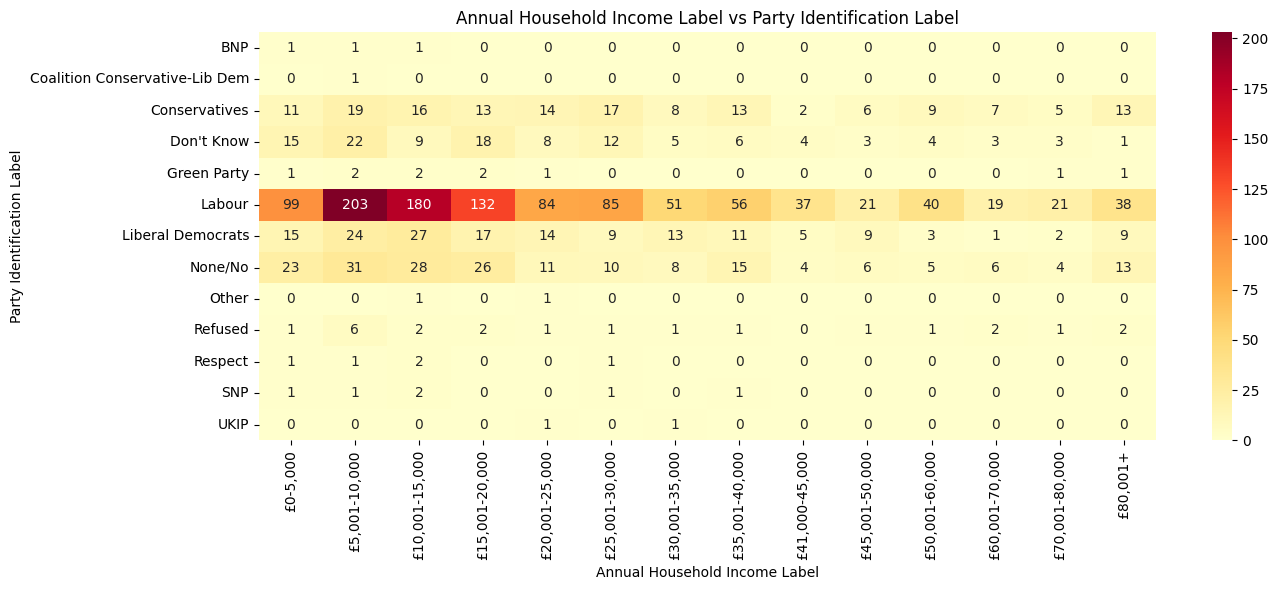

In [67]:
#Income Clean vs Party Identification

table_clean3 = pd.crosstab(df_incomclean['Party Identification Label'], df_incomclean['Annual Household Income Label'])
table_clean3 = table_clean3.reindex(columns=income_order).fillna(0).astype(int)
print(table_clean3)

table_clean3 = table_clean3.loc[:, table_clean3.sum() > 0]

chi2,p,dof,expected = chi2_contingency(table_clean3)
print("-" * 75)
print(f"STATISTICAL RESULTS: Annual Household Income Label vs Party Identification Label")
print("-" * 75)
print(f"chi_square statistic: {chi2:.3f}")
print(f"p_value:{p:.5f}")
print(f"dof:{dof}")
print("-" * 75)

plt.figure(figsize=(14, 6))
sns.heatmap(table_clean3, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Annual Household Income Label vs Party Identification Label')
plt.xlabel('Annual Household Income Label')
plt.ylabel('Party Identification Label')
plt.tight_layout()
plt.show()

In-Depth Analysis

Indian Population:

---------------------------------------------
STATISTICAL RESULTS: INDIAN MINORITY GROUP
---------------------------------------------
Chi-Square Statistic: 80.379
P-value:              0.40444
Degrees of Freedom:   78
Sample Size (n):      386
---------------------------------------------


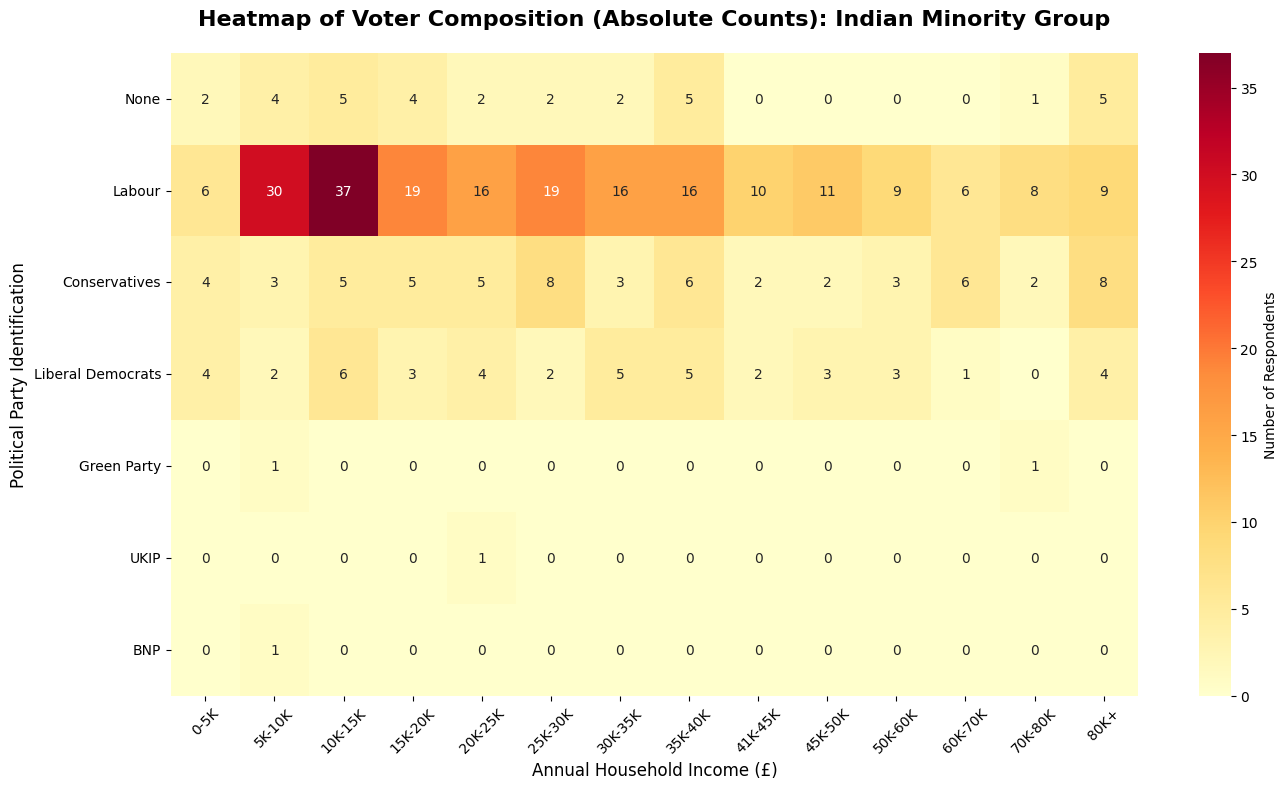

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df = pd.read_stata('BSE_2010.dta', convert_categoricals=False)
target_eth_code = 7
target_name = "Indian Minority Group"
df_sub = df[(df['zqinc'] >= 1) & (df['zqinc'] <= 14) & (df['zq101'] == target_eth_code)].copy()
party_map = {1:"None", 2:"Labour", 3:"Conservatives", 4:"Liberal Democrats",
             5:"Scottish National Party", 6:"Plaid Cymru", 7:"Green Party",
             8:"UKIP", 9:"BNP", 10:"Other"}
df_sub['Party_Name'] = df_sub['bq9_1'].map(party_map)
con_table = pd.crosstab(df_sub['zqinc'], df_sub['Party_Name'])
chi2, p, dof, expected = chi2_contingency(con_table)
requested_order = ["None", "Labour", "Conservatives", "Liberal Democrats",
                   "Scottish National Party", "Plaid Cymru", "Green Party",
                   "UKIP", "BNP", "Other"]
existing_parties = [p for p in requested_order if p in con_table.columns]
con_table = con_table[existing_parties]
plt.figure(figsize=(14, 8))
income_labels = ["0-5K","5K-10K","10K-15K","15K-20K","20K-25K","25K-30K","30K-35K",
                 "35K-40K","41K-45K","45K-50K","50K-60K","60K-70K","70K-80K","80K+"]
sns.heatmap(con_table.T,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            xticklabels=income_labels,
            cbar_kws={'label': 'Number of Respondents'})

plt.title(f'Heatmap of Voter Composition (Absolute Counts): {target_name}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Household Income (£)', fontsize=12)
plt.ylabel('Political Party Identification', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("-" * 45)
print(f"STATISTICAL RESULTS: {target_name.upper()}")
print("-" * 45)
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value:              {p:.5f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Sample Size (n):      {len(df_sub)}")
print("-" * 45)

Bangladesh Population:

---------------------------------------------
STATISTICAL RESULTS: BANGLADESHI MINORITY GROUP
---------------------------------------------
Chi-Square Statistic: 35.380
P-value:              0.91189
Degrees of Freedom:   48
Sample Size (n):      154
---------------------------------------------


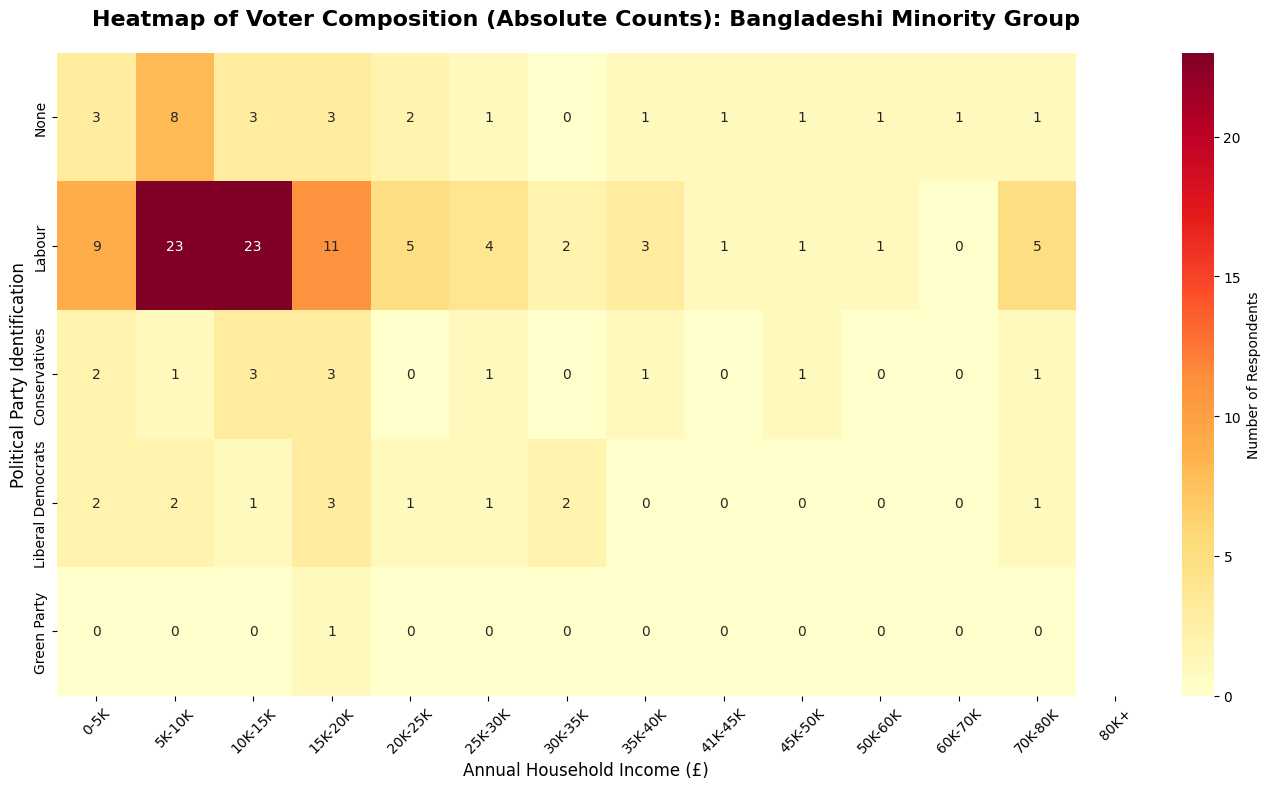

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df = pd.read_stata('BSE_2010.dta', convert_categoricals=False)
target_eth_code = 9
target_name = "Bangladeshi Minority Group"
df_sub = df[(df['zqinc'] >= 1) & (df['zqinc'] <= 14) & (df['zq101'] == target_eth_code)].copy()
party_map = {1:"None", 2:"Labour", 3:"Conservatives", 4:"Liberal Democrats",
             5:"Scottish National Party", 6:"Plaid Cymru", 7:"Green Party",
             8:"UKIP", 9:"BNP", 10:"Other"}
df_sub['Party_Name'] = df_sub['bq9_1'].map(party_map)
con_table = pd.crosstab(df_sub['zqinc'], df_sub['Party_Name'])
chi2, p, dof, expected = chi2_contingency(con_table)
requested_order = ["None", "Labour", "Conservatives", "Liberal Democrats",
                   "Scottish National Party", "Plaid Cymru", "Green Party",
                   "UKIP", "BNP", "Other"]
existing_parties = [p for p in requested_order if p in con_table.columns]
con_table = con_table[existing_parties]
plt.figure(figsize=(14, 8))
income_labels = ["0-5K","5K-10K","10K-15K","15K-20K","20K-25K","25K-30K","30K-35K",
                 "35K-40K","41K-45K","45K-50K","50K-60K","60K-70K","70K-80K","80K+"]
sns.heatmap(con_table.T,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            xticklabels=income_labels,
            cbar_kws={'label': 'Number of Respondents'})
plt.title(f'Heatmap of Voter Composition (Absolute Counts): {target_name}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Household Income (£)', fontsize=12)
plt.ylabel('Political Party Identification', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("-" * 45)
print(f"STATISTICAL RESULTS: {target_name.upper()}")
print("-" * 45)
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value:              {p:.5f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Sample Size (n):      {len(df_sub)}")
print("-" * 45)


Pakistan Population:

---------------------------------------------
STATISTICAL RESULTS: PAKISTANI MINORITY GROUP
---------------------------------------------
Chi-Square Statistic: 55.848
P-value:              0.78363
Degrees of Freedom:   65
Sample Size (n):      340
---------------------------------------------


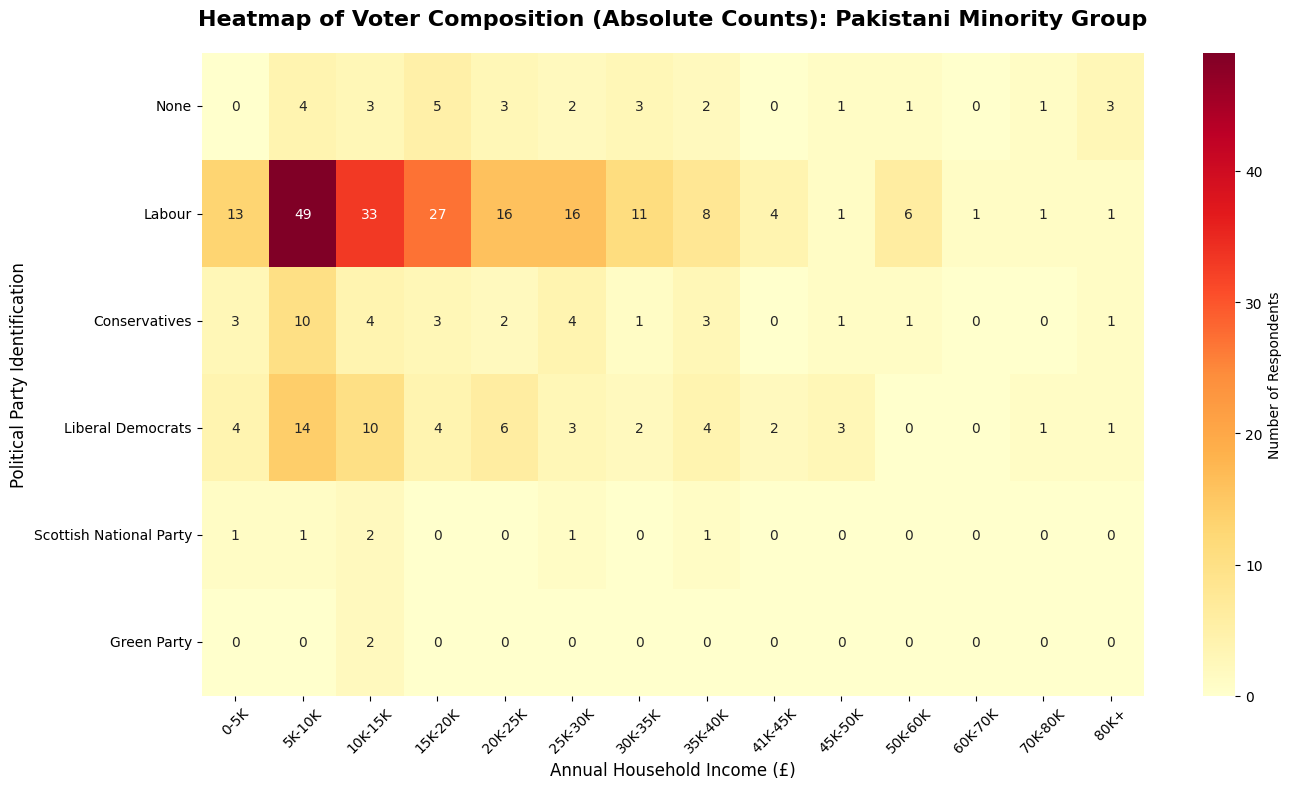

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df = pd.read_stata('BSE_2010.dta', convert_categoricals=False)
target_eth_code = 8
target_name = "Pakistani Minority Group"
df_sub = df[(df['zqinc'] >= 1) & (df['zqinc'] <= 14) & (df['zq101'] == target_eth_code)].copy()
party_map = {1:"None", 2:"Labour", 3:"Conservatives", 4:"Liberal Democrats",
             5:"Scottish National Party", 6:"Plaid Cymru", 7:"Green Party",
             8:"UKIP", 9:"BNP", 10:"Other"}
df_sub['Party_Name'] = df_sub['bq9_1'].map(party_map)
con_table = pd.crosstab(df_sub['zqinc'], df_sub['Party_Name'])
chi2, p, dof, expected = chi2_contingency(con_table)
requested_order = ["None", "Labour", "Conservatives", "Liberal Democrats",
                   "Scottish National Party", "Plaid Cymru", "Green Party",
                   "UKIP", "BNP", "Other"]
existing_parties = [p for p in requested_order if p in con_table.columns]
con_table = con_table[existing_parties]

plt.figure(figsize=(14, 8))
income_labels = ["0-5K","5K-10K","10K-15K","15K-20K","20K-25K","25K-30K","30K-35K",
                 "35K-40K","41K-45K","45K-50K","50K-60K","60K-70K","70K-80K","80K+"]

sns.heatmap(con_table.T,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            xticklabels=income_labels,
            cbar_kws={'label': 'Number of Respondents'})

plt.title(f'Heatmap of Voter Composition (Absolute Counts): {target_name}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Household Income (£)', fontsize=12)
plt.ylabel('Political Party Identification', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("-" * 45)
print(f"STATISTICAL RESULTS: {target_name.upper()}")
print("-" * 45)
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value:              {p:.5f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Sample Size (n):      {len(df_sub)}")
print("-" * 45)

Black Caribbean Population:

---------------------------------------------
STATISTICAL RESULTS: BLACK CARIBBEAN MINORITY GROUP
---------------------------------------------
Chi-Square Statistic: 72.240
P-value:              0.25117
Degrees of Freedom:   65
Sample Size (n):      402
---------------------------------------------


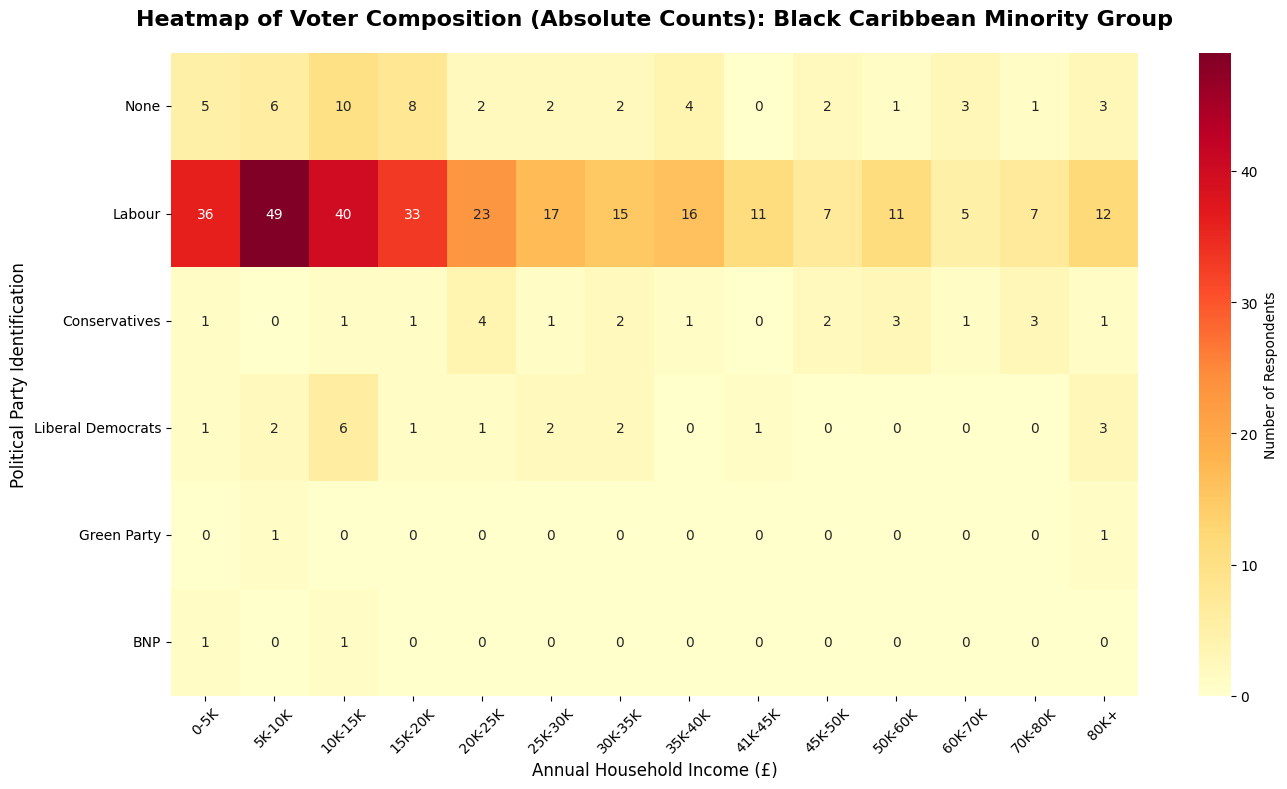

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df = pd.read_stata('BSE_2010.dta', convert_categoricals=False)
target_eth_code = 11
target_name = "Black Caribbean Minority Group"
df_sub = df[(df['zqinc'] >= 1) & (df['zqinc'] <= 14) & (df['zq101'] == target_eth_code)].copy()
party_map = {1:"None", 2:"Labour", 3:"Conservatives", 4:"Liberal Democrats",
             5:"Scottish National Party", 6:"Plaid Cymru", 7:"Green Party",
             8:"UKIP", 9:"BNP", 10:"Other"}
df_sub['Party_Name'] = df_sub['bq9_1'].map(party_map)

con_table = pd.crosstab(df_sub['zqinc'], df_sub['Party_Name'])
chi2, p, dof, expected = chi2_contingency(con_table)

requested_order = ["None", "Labour", "Conservatives", "Liberal Democrats",
                   "Scottish National Party", "Plaid Cymru", "Green Party",
                   "UKIP", "BNP", "Other"]
existing_parties = [p for p in requested_order if p in con_table.columns]
con_table = con_table[existing_parties]

plt.figure(figsize=(14, 8))
income_labels = ["0-5K","5K-10K","10K-15K","15K-20K","20K-25K","25K-30K","30K-35K",
                 "35K-40K","41K-45K","45K-50K","50K-60K","60K-70K","70K-80K","80K+"]
sns.heatmap(con_table.T,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            xticklabels=income_labels,
            cbar_kws={'label': 'Number of Respondents'})

plt.title(f'Heatmap of Voter Composition (Absolute Counts): {target_name}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Household Income (£)', fontsize=12)
plt.ylabel('Political Party Identification', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("-" * 45)
print(f"STATISTICAL RESULTS: {target_name.upper()}")
print("-" * 45)
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value:              {p:.5f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Sample Size (n):      {len(df_sub)}")
print("-" * 45)

Black African Population:

---------------------------------------------
STATISTICAL RESULTS: BLACK AFRICAN MINORITY GROUP
---------------------------------------------
Chi-Square Statistic: 50.293
P-value:              0.54127
Degrees of Freedom:   52
Sample Size (n):      351
---------------------------------------------


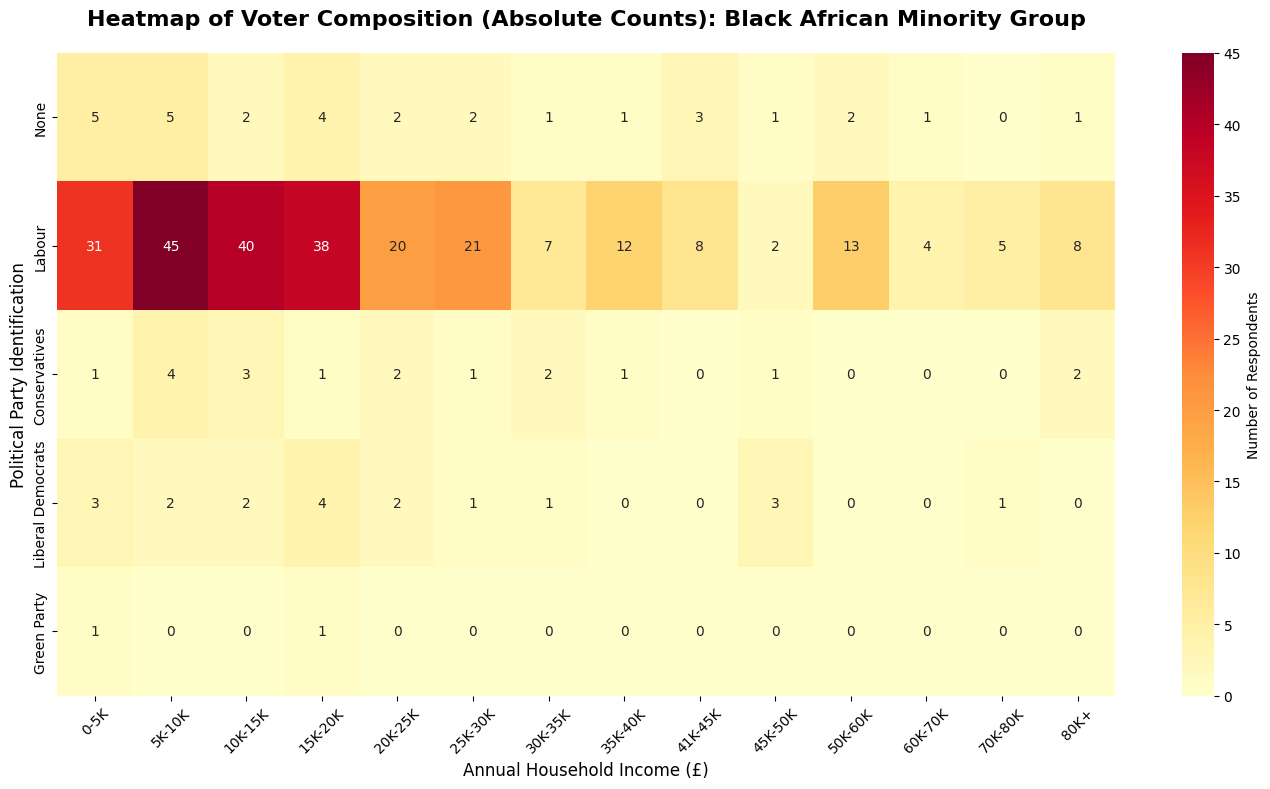

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
df = pd.read_stata('BSE_2010.dta', convert_categoricals=False)
target_eth_code = 12
target_name = "Black African Minority Group"
df_sub = df[(df['zqinc'] >= 1) & (df['zqinc'] <= 14) & (df['zq101'] == target_eth_code)].copy()
party_map = {1:"None", 2:"Labour", 3:"Conservatives", 4:"Liberal Democrats",
             5:"Scottish National Party", 6:"Plaid Cymru", 7:"Green Party",
             8:"UKIP", 9:"BNP", 10:"Other"}
df_sub['Party_Name'] = df_sub['bq9_1'].map(party_map)
con_table = pd.crosstab(df_sub['zqinc'], df_sub['Party_Name'])
chi2, p, dof, expected = chi2_contingency(con_table)

requested_order = ["None", "Labour", "Conservatives", "Liberal Democrats",
                   "Scottish National Party", "Plaid Cymru", "Green Party",
                   "UKIP", "BNP", "Other"]
existing_parties = [p for p in requested_order if p in con_table.columns]
con_table = con_table[existing_parties]

plt.figure(figsize=(14, 8))
income_labels = ["0-5K","5K-10K","10K-15K","15K-20K","20K-25K","25K-30K","30K-35K",
                 "35K-40K","41K-45K","45K-50K","50K-60K","60K-70K","70K-80K","80K+"]
sns.heatmap(con_table.T,
            annot=True,
            fmt="d",
            cmap="YlOrRd",
            xticklabels=income_labels,
            cbar_kws={'label': 'Number of Respondents'})

plt.title(f'Heatmap of Voter Composition (Absolute Counts): {target_name}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Annual Household Income (£)', fontsize=12)
plt.ylabel('Political Party Identification', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

print("-" * 45)
print(f"STATISTICAL RESULTS: {target_name.upper()}")
print("-" * 45)
print(f"Chi-Square Statistic: {chi2:.3f}")
print(f"P-value:              {p:.5f}")
print(f"Degrees of Freedom:   {dof}")
print(f"Sample Size (n):      {len(df_sub)}")
print("-" * 45)

In [73]:
conclutions = {
    'Test': [
        'Ethnicity vs Closer to Party',
        'Income vs Ethnicity',
        'Income vs Closer to Party',
        'Income vs Party Identification',
        'Ethnicity vs Party Identification',
        'Income Clean vs Ethnicity',
        'Income Clean vs Closer to Party',
        'Income Clean vs Party Identification',
        'Voter Composition Indian Minority Group',
        'Voter Composition Bangladeshi Minority Group',
        'Voter Composition Pakistani Minority Group',
        'Voter Composition Black Caribbean Minority Group',
        'Voter Composition Black African Minority Group'
    ],
    'Chi²': [19.450, 194.163, 38.955, 182.160, 203.141, 130.093, 27.983, 134.265, 80.379, 35.380, 55.848, 72.240, 50.293],
    'p-value': [0.07824, 0.00000, 0.72478, 0.44097, 0.00000, 0.00000, 0.90518, 0.89518, 0.40444, 0.91189, 0.78363, 0.25117, 0.54127],
    'dof': [12, 60, 45, 180, 48, 52, 39, 156, 78, 48, 65, 65, 52],
    'Significant?': ['No','Yes','No','No','Yes','Yes','No','No','No','No','No','No','No']
}
df_results = pd.DataFrame(conclutions)
df_results

,Test,Chi²,p-value,dof,Significant?
0,Ethnicity vs Closer to Party,19.450,0.07824,12,No
1,Income vs Ethnicity,194.163,0.00000,60,Yes
2,Income vs Closer to Party,38.955,0.72478,45,No
3,Income vs Party Identification,182.160,0.44097,180,No
4,Ethnicity vs Party Identification,203.141,0.00000,48,Yes
5,Income Clean vs Ethnicity,130.093,0.00000,52,Yes
6,Income Clean vs Closer to Party,27.983,0.90518,39,No
7,Income Clean vs Party Identification,134.265,0.89518,156,No
8,Voter Composition Indian Minority Group,80.379,0.40444,78,No
9,Voter Composition Bangladeshi Minority Group,35.380,0.91189,48,No


In [74]:
# Answer Define the analysis required to answer the RQ and explain why you have chosen this particular analysis.
# The research question is: "Does Annual Household Income Play a Role in Minority’s Political Party Identification?"

#Annual Household Income does NOT directly influence party identification among ethnic minorities (p > 0.05 in all income-party tests).

#However, the analysis show
#.      1. Income IS significantly associated with Ethnicity (p = 0.0000) - income distribution varies
#.         across ethnic groups.
#.      2. Ethnicity IS significantly associated with Party Identification (p = 0.0000) - different ethnic
#.         groups identify with different parties.
#.      3. But Income itself does NOT predict Party Identification (p = 0.44/0.89) knowing someone's
#.         income does not help predict their party choice.

#This shows that ethnicity is the key driver of party identification among ethnic minorities in the UK.
#The relationship between income and ethnicity exists, but income does not translate into party  preferences
#independently.

#In-depth Analysis: specific ethnic group breakdown
#While the aggregate analysis of the total population provides a statistically robust baseline, it risks masking significant internal variations
#through the "averaging out" of diverse cultural experiences. To ensure the integrity of our conclusions, it is essential to conduct a
#disaggregated analysis of individual ethnic minority groups.
#The purpose of this in-depth breakdown is twofold: to verify if the "income-neutral" voting pattern is a universal characteristic among
#minorities or if specific groups deviate from the aggregate trend, and to provide a granular view of the relationship between socioeconomic
#mobility and political loyalty, thereby testing the limits of the class-alignment theory across different cultural backgrounds.
#To test the independence between Annual Household Income and Political Party Identification, a series of Chi-Square tests was performed for
#each sub-sample. The resulting Chi-Square P-Value for the selected groups are as follows:
#Indian: p=0.4000
#Pakistani: p=0.7836
#Bangladeshi: p=0.9100
#Black Caribbean: p=0.2512
#Black African: p=0.5413
#The results across all disaggregated categories are remarkably consistent. In every single case, the p-value is significantly higher than the
#standard critical threshold of 0.05. Particularly striking are the results for the Bangladeshi (p=0.91) and Pakistani (p=0.78) groups, which
#show almost total statistical independence between wealth and party choice. Even the Black Caribbean group, which represents the lowest p-value
#in this set (0.25), remains well within the territory of non-significance.

#The high p-values observed across all specific ethnic groups are entirely coherent with the result of the study. This uniformity
#confirms that the lack of a relationship between income and political orientation is not a statistical anomaly of the total population, but rather
#a deeply rooted characteristic shared across various minority demographics.


In [75]:
#7. List all assumptions and how you addressed them.

#- 1. All variables used in the Chi-Square tests are categorical.

#- 2. When the Chi-Square value for Income vs Ethnicity was obtained, it showed a highly significant relationship. However, it was
#.    necessary to determine whether this relationship could be affected by respondents in categories -2 (Refused) and -1 (Don't Know),
#.    which are not valid income categories and contained a large portion of respondents. After running the analysis without these values,
#.    the relationship remained significant, confirming it is real and that the presence of these two groups was only inflating the result.
#.    Income distribution varies significantly across ethnic groups.

#- 3. A sufficient sample size is required, generally a minimum of n > 50. The dataset contains 1,732 wich exceeds the minimum requirement.

#- 4. A concern arose about whether each respondent appears only once in the table or if there are duplicate IDs that could be affecting the
#.    analysis. To address this, the number of unique IDs was compared against the total number of rows, which showed that there are no duplicate
#.    IDs and each person appears only once.

df_incomclean['Unique ID'].nunique() == len(df_incomclean)

True

In [76]:
#8. List the null and alternative hypothesis.

data = {
    'Test': [
        'Ethnicity vs Closer to Party',
        'Income vs Ethnicity',
        'Income vs Closer to Party',
        'Income vs Party Identification',
        'Ethnicity vs Party Identification'
    ],
    'H0 (Null Hypothesis)': [
        'Ethnicity and Closer to Party are independent.',
        'Income and Ethnicity are independent.',
        'Income and Closer to Party are independent.',
        'Income and Party Identification are independent.',
        'Ethnicity and Party Identification are independent.'
    ],
    'H1 (Alternative Hypothesis)': [
        'Ethnicity and Closer to Party are NOT independent.',
        'Income and Ethnicity are NOT independent.',
        'Income and Closer to Party are NOT independent.',
        'Income and Party Identification are NOT independent.',
        'Ethnicity and Party Identification are NOT independent.'
    ],
    'p-value': [0.07824, 0.00000, 0.72478, 0.44097, 0.00000],
    'Result': [
        'Fail to reject H0 - No evidence of a relationship',
        'Reject H0 - Significant relationship exists',
        'Fail to reject H0 - No evidence of a relationship',
        'Fail to reject H0 - No evidence of a relationship',
        'Reject H0 - Significant relationship exists'
    ]
}

df_hypotheses = pd.DataFrame(data)
df_hypotheses

,Test,H0 (Null Hypothesis),H1 (Alternative Hypothesis),p-value,Result
0,Ethnicity vs Closer to Party,Ethnicity and Closer to Party are independent.,Ethnicity and Closer to Party are NOT independ...,0.07824,Fail to reject H0 - No evidence of a relationship
1,Income vs Ethnicity,Income and Ethnicity are independent.,Income and Ethnicity are NOT independent.,0.00000,Reject H0 - Significant relationship exists
2,Income vs Closer to Party,Income and Closer to Party are independent.,Income and Closer to Party are NOT independent.,0.72478,Fail to reject H0 - No evidence of a relationship
3,Income vs Party Identification,Income and Party Identification are independent.,Income and Party Identification are NOT indepe...,0.44097,Fail to reject H0 - No evidence of a relationship
4,Ethnicity vs Party Identification,Ethnicity and Party Identification are indepen...,Ethnicity and Party Identification are NOT ind...,0.00000,Reject H0 - Significant relationship exists


In [77]:
#Each test evaluates two hypotheses:
#- H0: the two variables are independent (no relationship)
#- H1: the two variables are NOT independent (there is a relationship)

#The decision rule is based on the p-value with a significance level of 0.05:
#- If p-value < 0.05: Reject H0 → there is a significant relationship
#- If p-value >= 0.05: Fail to reject H0 → no evidence of relationship

#Key findings:
#- Income does NOT influence whether minorities feel close to a party (p = 0.72) or which party they identify with (p = 0.44).
#- Ethnicity DOES significantly influence party identification (p = 0.00000), meaning different ethnic groups tend to identify
#with different political parties.
#- Income and Ethnicity ARE significantly related (p = 0.00000), meaning income distribution varies across ethnic groups.

#In conclusion, Annual Household Income does not directly influence party identification among ethnic minorities. Ethnicity is the key
#factor that determines party identification.

In [78]:
#9  Provide the results of your analysis and answer the research question.

#Annual Household Income does NOT directly influence party identification among ethnic minorities.
#This is confirmed by p-values well above 0.05 in all income-party tests (p = 0.44 and p = 0.89), meaning we fail to reject the null
#hypothesis of independence between income and party identification.

#However, the analysis reveals an important pattern
#-	Income IS significantly associated with Ethnicity (p = 0.00000): income distribution varies across ethnic groups.
#-	Ethnicity IS significantly associated with Party Identification (p = 0.00000): different ethnic groups tend to identify with different
#.  political parties.
#-  Income alone does NOT predict Party Identification (p = 0.44/0.89): knowing someone's income level does not help predict which party
#   they will identify with. These results were consistent even after removing invalid response categories (-2 Refused and -1 Don't Know),
#.  confirming that the findings are robust and not inflated by non-substantive responses.

#While economic differences exist between ethnic groups, these differences do not translate into different party preferences.

In [79]:
#10. Try to explain the impact of the result within the context of the data.

#The British Election Study Ethnic Minority Survey 2010 collected data from 2,787 respondents across five ethnic groups: Indian, Pakistani,
#Bangladeshi, Black Caribbean, and Black African in the UK.

#For a long time, annual household income has been considered a factor that directly influences political decisions. However, the analysis
#demonstrates the opposite: income does not determine how ethnic minorities align politically. Regardless of whether a person earns
#£0-5,000 or £80,001+, their income level does not predict which party they identify with (p = 0.44) or whether they feel close to
#any party at all (p = 0.72).

#In contrast, ethnicity plays a significant role. Different ethnic groups show distinct patterns of party identification (p = 0.00000).
#This suggests that cultural background, community ties, and shared experiences within each ethnic group are stronger drivers of political
#identity than economic status.

#An interesting finding is that income distribution does vary significantly across ethnic groups (p = 0.00000). For example,
#the heatmap showed that Black African respondents are concentrated in lower income bands, while Indian respondents show greater presence
#in higher income bands. Yet despite these economic differences between groups, income alone does not translate into different party preferences.

#This has practical implications: political parties seeking to attract ethnic minority voters should focus on culturally relevant messaging
#tailored to each ethnic group rather than strategies based on economic segmentation, as the political identity of these communities is shaped
#more by ethnicity than by income level.

